In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("algeas.csv")
df.head()

,Light,Nitrate,Iron,Phosphate,Temperature,pH,CO2,Population
0,1011.00,1.11,0.17,0.08,23.39,7.27,9.22,4736.51
1,1206.50,3.29,0.14,0.04,14.74,7.94,9.59,4677.34
2,1450.63,1.67,0.04,0.02,28.58,7.35,4.46,3388.85
3,1158.40,2.48,0.09,0.06,27.18,7.43,6.34,4899.17
4,1159.92,2.15,0.15,0.08,22.52,7.92,6.46,4974.25


In [4]:
df["Bloom"] = (df["Population"] > 3500).astype(int)

In [5]:
df.head()

,Light,Nitrate,Iron,Phosphate,Temperature,pH,CO2,Population,Bloom
0,1011.00,1.11,0.17,0.08,23.39,7.27,9.22,4736.51,1
1,1206.50,3.29,0.14,0.04,14.74,7.94,9.59,4677.34,1
2,1450.63,1.67,0.04,0.02,28.58,7.35,4.46,3388.85,0
3,1158.40,2.48,0.09,0.06,27.18,7.43,6.34,4899.17,1
4,1159.92,2.15,0.15,0.08,22.52,7.92,6.46,4974.25,1


In [6]:
df.columns

Index(['Light', 'Nitrate', 'Iron', 'Phosphate', 'Temperature', 'pH', 'CO2',
       'Population', 'Bloom'],
      dtype='object')

In [7]:
x = df[['Light', 'Nitrate', 'Iron', 'Phosphate', 'Temperature', 'pH', 'CO2',
       ]]

In [8]:
y = df["Bloom"]

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2, random_state= 42)

In [10]:
dt_model = DecisionTreeClassifier(random_state= 42)
dt_model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [11]:
dt_predicitions =  dt_model.predict(x_test)
dt_acc = accuracy_score(y_test, dt_predicitions)
print(f"Decision Tree Accuray: {dt_acc *100:.2f}%")

Decision Tree Accuray: 92.85%


In [15]:
rf_model = RandomForestClassifier(n_estimators = 100 , oob_score = True, random_state = 42)
rf_model.fit(x_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
rf_prediction = rf_model.predict(x_test)
rf_acc = accuracy_score(y_test, rf_prediction)
oob_value =  rf_model.oob_score_
print(f"Random Forest Classifier Accuray : {rf_acc*100:.2f}%")
print(f"Random Forest OOB Score: {oob_value*100:.2f}%")

Random Forest Classifier Accuray : 94.58%
Random Forest OOB Score: 94.44%


In [13]:
x_train.head()

,Light,Nitrate,Iron,Phosphate,Temperature,pH,CO2
7359,1127.10,5.25,0.16,0.17,10.46,7.81,4.03
8988,1414.84,1.62,0.10,0.15,24.21,7.30,2.22
8295,48.88,3.20,0.13,0.13,28.25,7.34,6.94
9629,1210.49,1.55,0.16,0.14,19.79,7.22,6.98
4058,1438.50,2.84,0.13,0.01,15.55,7.30,4.68


In [14]:
x_test.head()

,Light,Nitrate,Iron,Phosphate,Temperature,pH,CO2
6582,1845.89,1.86,0.11,0.09,29.36,7.56,6.15
8509,1908.49,5.66,0.17,0.12,22.13,7.05,8.42
5657,1407.66,7.36,0.04,0.06,27.33,7.48,5.77
5030,1219.40,1.77,0.13,0.05,26.97,7.55,5.51
2272,1547.97,7.96,0.15,0.15,20.66,7.95,8.59


In [17]:
from sklearn.ensemble import GradientBoostingClassifier

In [18]:
boost_model = GradientBoostingClassifier(n_estimators= 100, random_state= 42)

In [19]:
boost_model.fit(x_train, y_train)
boost_prediction = boost_model.predict(x_test)
boost_acc =  accuracy_score(y_test, boost_prediction)
print(f"Boosting Accuracy:{boost_acc*100:.2f}%")

Boosting Accuracy:94.63%


In [20]:
df.head()

,Light,Nitrate,Iron,Phosphate,Temperature,pH,CO2,Population,Bloom
0,1011.00,1.11,0.17,0.08,23.39,7.27,9.22,4736.51,1
1,1206.50,3.29,0.14,0.04,14.74,7.94,9.59,4677.34,1
2,1450.63,1.67,0.04,0.02,28.58,7.35,4.46,3388.85,0
3,1158.40,2.48,0.09,0.06,27.18,7.43,6.34,4899.17,1
4,1159.92,2.15,0.15,0.08,22.52,7.92,6.46,4974.25,1


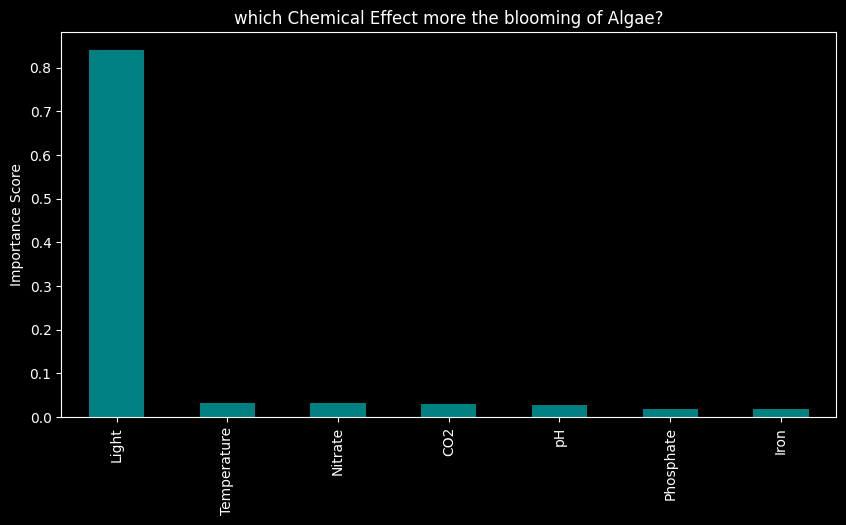

In [30]:
importance = pd.Series(rf_model.feature_importances_, index = x.columns).sort_values(ascending = False)
plt.figure(figsize=(10,5), facecolor = "black")
importance.plot(kind = "bar", color = "teal")
plt.title("which Chemical Effect more the blooming of Algae?")
plt.ylabel("Importance Score")
plt.show()

In [ ]:
import pickle 
with open("Algea_Model.pkl", "wb")as file:
    pickle.dump(rf_model, file)
print("Model Saved Successfully")

Model Saved Successfully
